# Project Overview

## Objective

This project aims to analyze the global data job market using publicly available job and salary data. The goal is to explore salary trendss, skill demand, remote work patterns, and geographic salary distribution within data-related roles.

By performing structured exploratory data analysis (EDA), this project will uncover meaningful insights that reflect current industry trends

## Why Job Market Analysis Matters

Understanding job market trends is essential for
* Identifying high-demand technical skills
* Estimating salary expectations across experience levels
* Comparing remote vs onsite opportunities
* Understanding geographic pay differences
* Making informed career development decisions

## Project Scope

This project focuses on
* Cleaning and preparing raw job market data
* Analyzing salary distributions
* Comparing salary trends by experience level
* Examining the impact of remote work on compensation
* Identifying the most in-demand skills
* Comparing median salaries across countries

## Business Questions

This analysis aims to answer the following questions.

1. What does the overall salary distribution look like for data-related roles?
2. How does salary vary by experience level (Entry, Mid, Senior, Executive)?
3. Do remote roles offer higher median salaries compared to onsite or hybrid roles?
4. Which technical skills are most frequently required in data job postings?
5. Which countries offer the highest median salaries for data roles?
6. Is there a noticeable salary difference based on company size?

### Environment Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
file_path = "../data/data_jobs.csv"
df = pd.read_csv(file_path)

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Research Scientist,208000,USD,208000,US,0,US,M
1,2025,MI,FT,Research Scientist,147000,USD,147000,US,0,US,M
2,2025,SE,FT,Research Scientist,173000,USD,173000,US,0,US,M
3,2025,SE,FT,Research Scientist,117000,USD,117000,US,0,US,M
4,2025,MI,FT,AI Engineer,100000,USD,100000,US,100,US,M


## Data Understanding

In [4]:
df.shape

(93597, 11)

This dataset contains 93597 rows and 11 columns.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 93597 entries, 0 to 93596
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           93597 non-null  int64
 1   experience_level    93597 non-null  str  
 2   employment_type     93597 non-null  str  
 3   job_title           93597 non-null  str  
 4   salary              93597 non-null  int64
 5   salary_currency     93597 non-null  str  
 6   salary_in_usd       93597 non-null  int64
 7   employee_residence  93597 non-null  str  
 8   remote_ratio        93597 non-null  int64
 9   company_location    93597 non-null  str  
 10  company_size        93597 non-null  str  
dtypes: int64(4), str(7)
memory usage: 7.9 MB


Most categorical variables are stored as object types, while salary-related columns are numeric.

In [6]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,93597.000000,9.359700e+04,93597.000000,93597.000000
mean,2024.086434,1.623541e+05,157547.696774,21.455816
std,0.641449,2.221425e+05,73649.113729,40.954704
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.062600e+05,106250.000000,0.000000
50%,2024.000000,1.470000e+05,146232.000000,0.000000
75%,2024.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


The salary_in_usd column shows a wide range, with a noticeable difference between median and maximum values

### Column Description

* work_year - Year the salary was recorded
* experience_level - Employee seniority level
* employment_type - Full-time, part-time, contract, Freelance
* job_title - Specific job role
* salary - Salary in original currency
* salary_currency - Currency type
* salary_in_usd - Salary standardized to USD
* employee_residence - Country of employee
* remote_ratio - Percentage of remote work
* company_location - company headquarters location
* company_size - Small(S), medium (M), Large (L)

In [8]:
df['experience_level'].unique()

<StringArray>
['MI', 'SE', 'EN', 'EX']
Length: 4, dtype: str

### Experience Level Mapping

* EN - Entry level
* MI - Mid level
* SE - Senior level
* EX - Executive level

In [9]:
df['employment_type'].unique()

<StringArray>
['FT', 'PT', 'CT', 'FL']
Length: 4, dtype: str

* FT - Full time
* PT - Part time
* CT - Contract
* FL - Freelance

In [10]:
df['remote_ratio'].unique()

array([  0, 100,  50])

In [11]:
df['company_size'].unique()

<StringArray>
['M', 'L', 'S']
Length: 3, dtype: str

* M - Medium
* L - Large
* S - Small

In [12]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(46960)

The dataset contains 46960 duplicate records. In the cleaning stage these will be removed.

For consistency and comparability across countries, salary_in_usd will be used as the primary salary metric in this analysis.

In [14]:
df['remote_ratio'].value_counts()

remote_ratio
0      73366
100    19933
50       298
Name: count, dtype: int64

* 0 = Onsite
* 50 = Hybrid
* 100 = Fully remote

In [15]:
df.duplicated().sum()

np.int64(46960)

In [16]:
df = df.drop_duplicates()

In [17]:
df.shape

(46637, 11)

The dataset originally contaned 46,960 duplicate records. These duplicates were removed to ensure analytical intergrity and prevent inflated insights.

In [18]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [20]:
experience_mapping = {
    'EN' : 'Entry-level',
    'MI' : 'Mid-level',
    'SE' : 'Senior-level',
    'EX' : 'Executive-levels'
}

df['experience_level'] = df['experience_level'].map(experience_mapping)

In [21]:
df['experience_level'].unique()

<StringArray>
['Mid-level', 'Senior-level', 'Entry-level', 'Executive-levels']
Length: 4, dtype: str

In [26]:
size_mapping = {
    'M' : 'Medium',
    'L' : 'Large',
    'S' : 'Small'
}

df['company_size'] = df['company_size'].map(size_mapping)

In [27]:
df['company_size'].unique()

<StringArray>
['Medium', 'Large', 'Small']
Length: 3, dtype: str

In [28]:
remote_mapping = {
    0: 'Onsite',
    50: 'Hybrid',
    100: 'Fully Remote'
}

df['remote_type'] = df['remote_ratio'].map(remote_mapping)

In [29]:
df['remote_type'].unique()

<StringArray>
['Onsite', 'Fully Remote', 'Hybrid']
Length: 3, dtype: str

In [30]:
df['salary_in_usd'].describe()

count     46637.000000
mean     151411.819993
std       77492.347696
min       15000.000000
25%       96400.000000
50%      139100.000000
75%      190500.000000
max      800000.000000
Name: salary_in_usd, dtype: float64

In [31]:
df[df['salary_in_usd'] <= 0]

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,company_sze,remote_type


In [32]:
df = df[df['salary_in_usd'] > 0]

Salary values less than or equal to zero can be removed from this but there was no values that equal to zero or negative

In [35]:
df.sort_values(by = 'salary_in_usd', ascending = False).head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,company_sze,remote_type
79867,2024,Mid-level,FT,AI Architect,800000,USD,800000,CA,100,CA,Medium,Medium,Fully Remote
13514,2025,Entry-level,FT,Data Engineer,753480,EUR,793136,AT,0,AT,Medium,Medium,Onsite
80710,2024,Entry-level,FT,Data Analyst,774000,USD,774000,MX,0,MX,Medium,Medium,Onsite
81685,2024,Mid-level,FT,Machine Learning Scientist,750000,USD,750000,US,0,US,Medium,Medium,Onsite
84453,2023,Mid-level,FT,Data Engineer,750000,USD,750000,US,0,US,Medium,Medium,Onsite


In [36]:
df['job_title'] = df['job_title'].str.strip()

In [38]:
median_salary = df['salary_in_usd'].median()

df['above_median_salary'] = df['salary_in_usd'] > median_salary

In [39]:
df.shape

(46637, 14)

In [40]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,company_sze,remote_type,above_median_salary
0,2025,Mid-level,FT,Research Scientist,208000,USD,208000,US,0,US,Medium,Medium,Onsite,True
1,2025,Mid-level,FT,Research Scientist,147000,USD,147000,US,0,US,Medium,Medium,Onsite,True
2,2025,Senior-level,FT,Research Scientist,173000,USD,173000,US,0,US,Medium,Medium,Onsite,True
3,2025,Senior-level,FT,Research Scientist,117000,USD,117000,US,0,US,Medium,Medium,Onsite,False
4,2025,Mid-level,FT,AI Engineer,100000,USD,100000,US,100,US,Medium,Medium,Fully Remote,False


In [41]:
df.info()

<class 'pandas.DataFrame'>
Index: 46637 entries, 0 to 93596
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   work_year            46637 non-null  int64
 1   experience_level     46637 non-null  str  
 2   employment_type      46637 non-null  str  
 3   job_title            46637 non-null  str  
 4   salary               46637 non-null  int64
 5   salary_currency      46637 non-null  str  
 6   salary_in_usd        46637 non-null  int64
 7   employee_residence   46637 non-null  str  
 8   remote_ratio         46637 non-null  int64
 9   company_location     46637 non-null  str  
 10  company_size         46637 non-null  str  
 11  company_sze          46637 non-null  str  
 12  remote_type          46637 non-null  str  
 13  above_median_salary  46637 non-null  bool 
dtypes: bool(1), int64(4), str(9)
memory usage: 5.0 MB


In [43]:
median_salary

np.float64(139100.0)

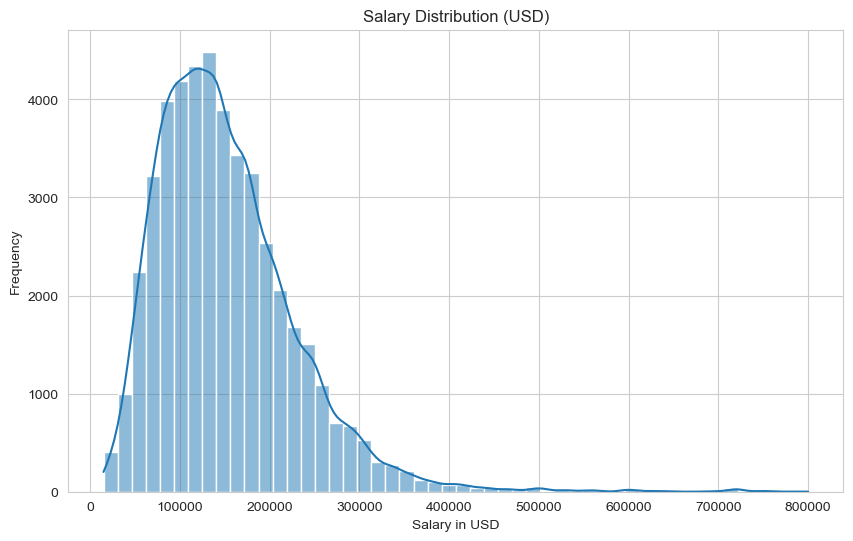

In [52]:
plt.figure(figsize = (10, 6))
sns.histplot(df['salary_in_usd'], bins = 50, kde = True)
plt.title("Salary Distribution (USD)")
plt.xlabel("Salary in USD")
plt.ylabel("Frequency")
plt.show()

The salary distribution is right-skewed, with the majority of salaries clustered below $200,000 and a smaller number of high-paying roles extending into the upper range.

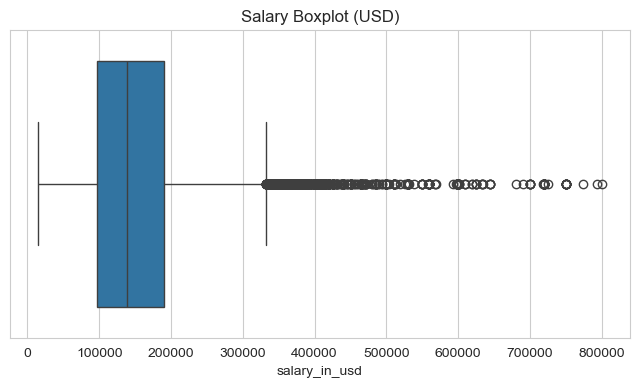

In [53]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['salary_in_usd'])
plt.title("Salary Boxplot (USD)")
plt.show()

The boxplot reveals a wide interquartile range, indicating variability in compensation across roles. Several high-end outliers suggest executive or specialized positions with significantly higher pay. It shows that most salaries fall between approximately 100,000 and 190,000 with a median around $145,000. The wide interquartile range indicates noticeable variability in pay.

In [54]:
df['salary_in_usd'].mean(), df['salary_in_usd'].median()

(np.float64(151411.81999270964), np.float64(139100.0))

mean > median → strong right skew.
The mean salary exceeds the median salary, reinforcing the presence of high-income outliers that elevate the average compensation.

In [55]:
df.groupby('work_year')['salary_in_usd'].median()

work_year
2020     79833.0
2021     82528.0
2022    129300.0
2023    142200.0
2024    140000.0
2025    138500.0
Name: salary_in_usd, dtype: float64

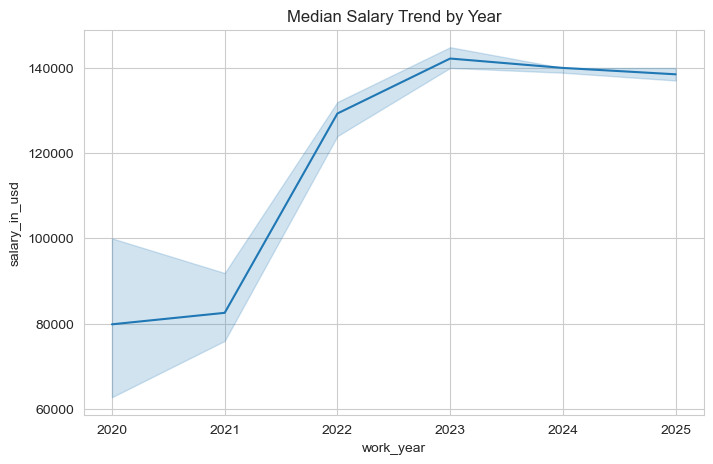

In [57]:
plt.figure(figsize= (8, 5))
sns.lineplot(x = 'work_year', y= 'salary_in_usd', data = df, estimator = 'median')
plt.title("Median Salary Trend by Year")
plt.show()

Median salaries show a noticeable upward trend over recent years, potentially reflecting increased demand for data professionals.

In [58]:
bins = [0, 80000, 150000, 250000, 1000000]
labels = ['Low', 'Mid', 'High', 'Very High']

df['salary_band'] = pd.cut(df['salary_in_usd'], bins = bins, labels = labels)
df['salary_band'].value_counts()

salary_band
Mid          18905
High         15643
Low           7595
Very High     4494
Name: count, dtype: int64

In [59]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,company_sze,remote_type,above_median_salary,salary_band
0,2025,Mid-level,FT,Research Scientist,208000,USD,208000,US,0,US,Medium,Medium,Onsite,True,High
1,2025,Mid-level,FT,Research Scientist,147000,USD,147000,US,0,US,Medium,Medium,Onsite,True,Mid
2,2025,Senior-level,FT,Research Scientist,173000,USD,173000,US,0,US,Medium,Medium,Onsite,True,High
3,2025,Senior-level,FT,Research Scientist,117000,USD,117000,US,0,US,Medium,Medium,Onsite,False,Mid
4,2025,Mid-level,FT,AI Engineer,100000,USD,100000,US,100,US,Medium,Medium,Fully Remote,False,Mid


In [60]:
df.sort_values(by = 'salary_in_usd', ascending = False).head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,company_sze,remote_type,above_median_salary,salary_band
79867,2024,Mid-level,FT,AI Architect,800000,USD,800000,CA,100,CA,Medium,Medium,Fully Remote,True,Very High
13514,2025,Entry-level,FT,Data Engineer,753480,EUR,793136,AT,0,AT,Medium,Medium,Onsite,True,Very High
80710,2024,Entry-level,FT,Data Analyst,774000,USD,774000,MX,0,MX,Medium,Medium,Onsite,True,Very High
81685,2024,Mid-level,FT,Machine Learning Scientist,750000,USD,750000,US,0,US,Medium,Medium,Onsite,True,Very High
84453,2023,Mid-level,FT,Data Engineer,750000,USD,750000,US,0,US,Medium,Medium,Onsite,True,Very High


#### Let's see how much does experience impact salary in data roles?

In [61]:
df.groupby('experience_level')['salary_in_usd'].median().sort_values()

experience_level
Entry-level          85428.0
Mid-level           123800.0
Senior-level        157267.0
Executive-levels    188640.0
Name: salary_in_usd, dtype: float64

Median salary increases consistently with experience level, confirming a strong compensation progression across career stages.

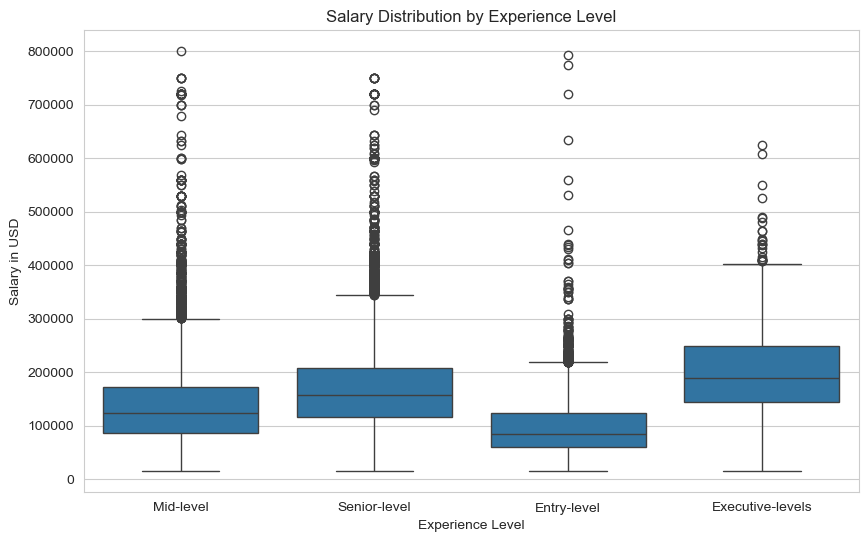

In [62]:
plt.figure(figsize=(10,6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df)
plt.title("Salary Distribution by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary in USD")
plt.show()

Entry-level roles show significantly lower compensation compared to mid and senior levels, while executive roles display both higher median salaries and greater variability.

In [64]:
median_salary_by_exp = df.groupby('experience_level')['salary_in_usd'].median()
median_salary_by_exp

experience_level
Entry-level          85428.0
Executive-levels    188640.0
Mid-level           123800.0
Senior-level        157267.0
Name: salary_in_usd, dtype: float64

In [69]:
entry = median_salary_by_exp['Entry-level']
mid = median_salary_by_exp['Mid-level']
senior = median_salary_by_exp['Senior-level']
exec_ = median_salary_by_exp['Executive-levels']

increase_entry_mid = (mid - entry) / entry * 100
increase_mid_senior = (senior - mid) / mid * 100
increase_senior_exec = (exec_ - senior) / senior * 100

increase_entry_mid, increase_mid_senior, increase_senior_exec

(np.float64(44.917357306737834),
 np.float64(27.033117932148627),
 np.float64(19.948876751003073))

Moving from Entry-level to Mid-level corresponds to approximately 44.917% salary growth.

In [68]:
df['experience_level'].value_counts()

experience_level
Senior-level        24749
Mid-level           15049
Entry-level          5391
Executive-levels     1448
Name: count, dtype: int64

In [70]:
df.groupby('remote_type')['salary_in_usd'].median().sort_values()

remote_type
Hybrid           66666.0
Onsite          139800.0
Fully Remote    139888.0
Name: salary_in_usd, dtype: float64

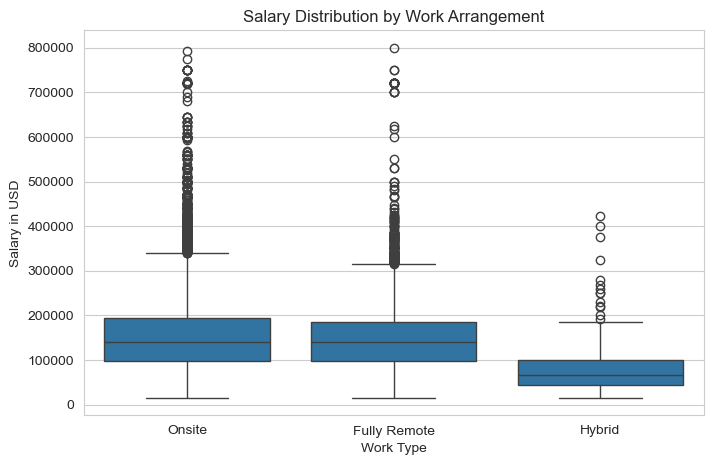

In [71]:
plt.figure(figsize=(8,5))
sns.boxplot(x='remote_type', y='salary_in_usd', data=df)
plt.title("Salary Distribution by Work Arrangement")
plt.xlabel("Work Type")
plt.ylabel("Salary in USD")
plt.show()

In [76]:
df.groupby('employment_type')['salary_in_usd'].head()

0        208000
1        147000
2        173000
3        117000
4        100000
20        44000
21        36000
750      338526
751       28206
864      138000
865      120000
896      138000
1699      62400
1700      41600
2233      69000
51812     61333
52626     60000
77948     36014
79302     30000
84784     21000
Name: salary_in_usd, dtype: int64

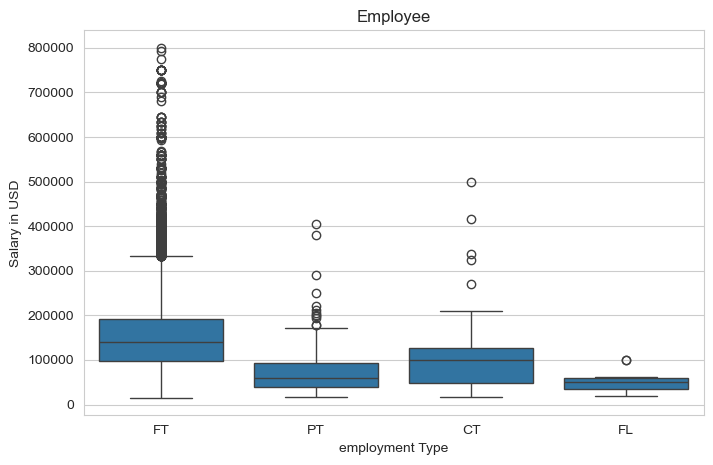

In [75]:
plt.figure(figsize=(8,5))
sns.boxplot(x='employment_type', y='salary_in_usd', data=df)
plt.title("Employee")
plt.xlabel("employment Type")
plt.ylabel("Salary in USD")
plt.show()

This shows that most of freelancers doesn't earn as much as other fulltime, parttime or contract

In [81]:
df['remote_type'].value_counts()

remote_type
Onsite          34848
Fully Remote    11493
Hybrid            296
Name: count, dtype: int64